In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [4]:
df = pd.DataFrame({
    'Customers':['A','B','C','D','E','F'],
    'Age':[20,30,40,22,38,25],
    'Spent':[100,200,300,120,290,150]
})

D:\coading\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  Customers  Age  Spent  Group
0         A   20    100      1
1         B   30    200      1
2         C   40    300      0
3         D   22    120      1
4         E   38    290      0
5         F   25    150      1


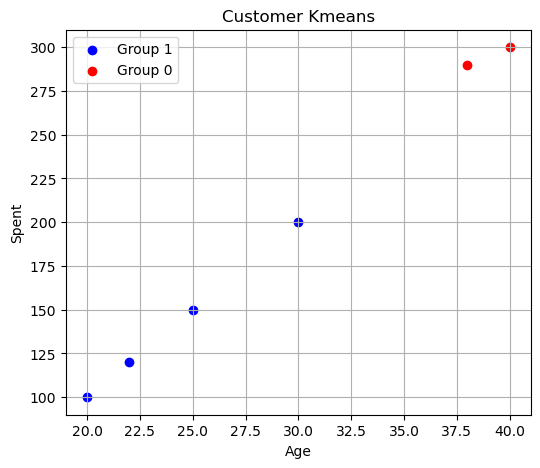

In [12]:
model = KMeans(n_clusters=2,n_init=10,random_state=42)

x= df[['Age','Spent']]
df['Group']=model.fit_predict(x)
colors={0:'red',1:'blue'}
print(df)

plt.figure(figsize=(6,5))
for g in df['Group'].unique():
    group_data=df[df['Group']==g]
    plt.scatter(group_data['Age'],group_data['Spent'],label=f'Group {g}',color=colors[g])
plt.xlabel("Age")
plt.ylabel('Spent')
plt.title('Customer Kmeans')
plt.grid(True)
plt.legend()
plt.show()


In [16]:
preminium_customer=df[df['Group']==0]
chindi_customer=df[df['Group']==1]

print('Premium Customer')
print(preminium_customer['Customers'],'\n')

print('Chindi Customer')
print(chindi_customer['Customers'])

Premium Customer
2    C
4    E
Name: Customers, dtype: object 

Chindi Customer
0    A
1    B
3    D
5    F
Name: Customers, dtype: object


D:\coading\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


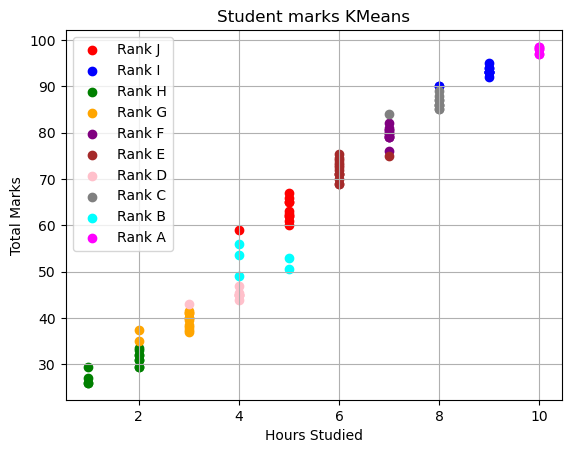

In [39]:
df=pd.read_csv('stdperfor.csv')
x=df[['Total_Marks','Hours_Studied']]
ranks=['A','B','C','D','E','F','G','H','I','J']
ranks=ranks[::-1]
colors = ['red','blue','green','orange','purple','brown','pink','gray','cyan','magenta']

model=KMeans(n_clusters=10,random_state=42,n_init=10)
df['Rank']=model.fit_predict(x)

for r in sorted(df['Rank'].unique()):
    data=df[df['Rank']==r]
    plt.scatter(data['Hours_Studied'],data['Total_Marks'],label=f'Rank {ranks[r]}',color=colors[r])

plt.title('Student marks KMeans')
plt.xlabel('Hours Studied')
plt.ylabel('Total Marks')
plt.legend()
plt.grid()
plt.show()



0     1
1     3
2     5
3     0
4     3
     ..
95    2
96    7
97    5
98    3
99    1
Name: Rank, Length: 100, dtype: int32


D:\coading\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


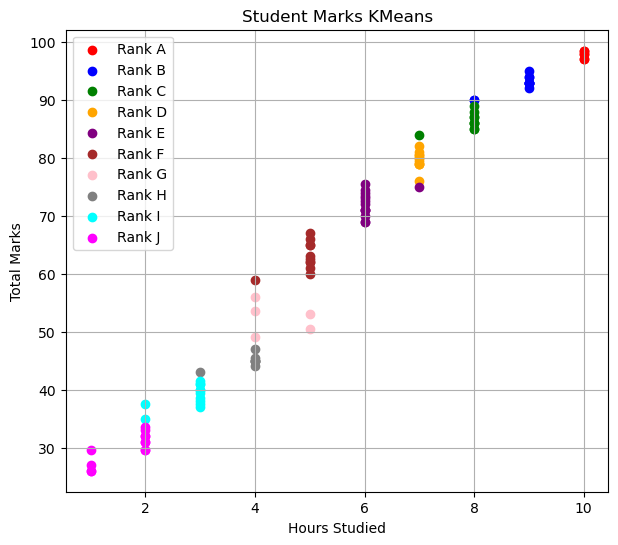

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 1: Load dataset
df = pd.read_csv('stdperfor.csv')

# Step 2: Features for clustering
x = df[['Total_Marks', 'Hours_Studied']]

# Step 3: Define ranks and colors in order

colors = ['red','blue','green','orange','purple','brown','pink','gray','cyan','magenta']

# Step 4: Train KMeans with 10 clusters
model = KMeans(n_clusters=10, random_state=42, n_init=10)
df['Cluster'] = model.fit_predict(x)

# Step 5: Get cluster centroids
centroids = model.cluster_centers_

# Step 6: Sort clusters by "Total_Marks" (Y-axis = upper means higher marks)
# If you want "upper" by Hours_Studied instead, change index [0] to [1]
sorted_clusters = sorted(range(len(centroids)), key=lambda c: centroids[c][0], reverse=True)

# Step 7: Create mapping cluster → rank
cluster_to_rank = {cluster: ranks[i] for i, cluster in enumerate(sorted_clusters)}

# Step 8: Plot clusters with ordered rank-color mapping
plt.figure(figsize=(7,6))
for cluster in sorted_clusters:
    data = df[df['Cluster'] == cluster]
    rank = cluster_to_rank[cluster]
    color = colors[ranks.index(rank)]
    plt.scatter( data['Hours_Studied'],data['Total_Marks'],
                color=color, label=f'Rank {rank}')


plt.title('Student Marks KMeans')
plt.ylabel('Total Marks')
plt.xlabel('Hours Studied')
plt.legend()
plt.grid(True)
plt.show()


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

       PCA1      PCA2
0 -2.901838  0.038962
1 -1.703939  0.088054
2 -0.585677 -0.001447
3  0.452949 -0.229542
4  1.730485 -0.041856
5  3.008020  0.145829
The ratio explanied by the PCA : 
99.65 % 0.35 %


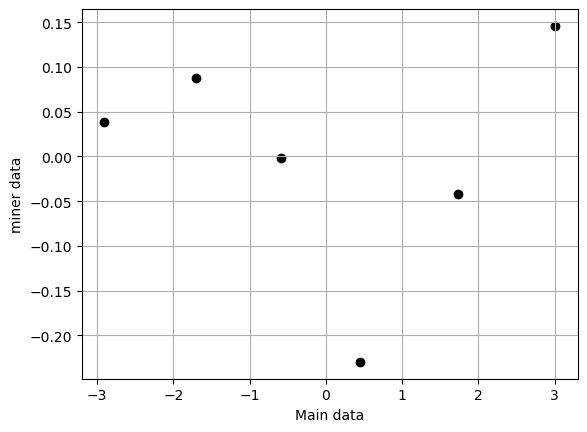

In [64]:
df=pd.DataFrame({
    'Age':[25,30,35,40,45,50],
    'Income':[30000,40000,50000,60000,70000,80000,],
    'Spend':[70,60,50,40,30,20],
    'Saving':[1000,5000,8000,10000,15000,20000]
})

scaler=StandardScaler()
scaled_data=scaler.fit_transform(df)

pca=PCA(n_components=2)
pca_result=pca.fit_transform(scaled_data)

pca_df=pd.DataFrame(pca_result,columns=['PCA1','PCA2'])
print(pca_df)


ratio_varience=pca.explained_variance_ratio_
print('The ratio explanied by the PCA : ')
print(np.round(ratio_varience[0]*100,2),'%',np.round(ratio_varience[1]*100,2),'%' )

plt.scatter(pca_df['PCA1'],pca_df['PCA2'],color='black')
plt.xlabel('Main data')
plt.ylabel('miner data')
plt.grid()
plt.show()

In [65]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA


In [137]:
# df=pd.read_csv('stdperfor.csv')

# df=df.drop(columns=['Unnamed: 0.1'])
# df.to_csv('stdperfor.csv')
# df

In [158]:
df=pd.read_csv('students_ML.csv')
passed=df.copy()
df=df.drop(columns=['Passed'])

df

,Unnamed: 0.1,Unnamed: 0,Student_ID,Gender,Age,Hours_Studied,Attendance,Sports,Internet_Access,Math_Marks,Science_Marks,Total_Marks
0,0,0,1001,0,-7.071068e-01,0.958502,1,0,1,1.032046,1.208568,1.120307
1,1,1,1002,1,7.071068e-01,-1.030092,0,1,1,-0.854773,-1.252317,-1.053545
2,2,2,1003,0,2.886580e-17,0.163065,1,0,1,0.329974,0.433845,0.381909
3,3,3,1004,1,-1.414214e+00,-0.234654,1,1,0,-0.284339,-0.158590,-0.221465
4,4,4,1005,0,1.414214e+00,-1.427811,0,0,1,-1.293568,-1.161173,-1.227370
...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,95,1096,1,-7.071068e-01,-1.427811,0,1,1,-1.512965,-1.434605,-1.473785
96,96,96,1097,0,7.071068e-01,0.560784,1,0,1,0.812648,0.889564,0.851106
97,97,97,1098,1,2.886580e-17,0.163065,1,1,1,0.286094,0.342701,0.314398
98,98,98,1099,0,-1.414214e+00,-1.030092,0,0,0,-1.249688,-1.161173,-1.205431


In [156]:
pca=PCA(n_components=3)
pca_result=pca.fit_transform(df)
pca_df=pd.DataFrame(pca_result,columns=['PCA1','PCA2','PCA3'])
print(pca_df)

pca_ratio=pca.explained_variance_ratio_
print(np.round(pca_ratio[0],2),'%',np.round(pca_ratio[1],2),'%',np.round(pca_ratio[2],2),'%')



         PCA1      PCA2      PCA3
0  -85.734436  2.389556 -0.448867
1  -84.006587 -2.213184  0.468028
2  -82.271733  0.868770  0.132634
3  -80.541001 -0.294164 -1.378839
4  -78.810606 -2.562547  1.225042
..        ...       ...       ...
95  78.804799 -3.041307 -1.065994
96  80.542079  1.518633  0.838932
97  82.272759  0.449016 -0.038630
98  84.001859 -2.299716 -1.549954
99  85.739701  2.294667  1.558418

[100 rows x 3 columns]
1.0 % 0.0 % 0.0 %


In [166]:
PCA1=pca_df['PCA1']
Passed=passed['Passed']

reduced_data=pd.DataFrame({
    'PCA1':PCA1,
    'Passed':Passed
})
print(reduced_data)

         PCA1  Passed
0  -85.734436       1
1  -84.006587       0
2  -82.271733       1
3  -80.541001       1
4  -78.810606       0
..        ...     ...
95  78.804799       0
96  80.542079       1
97  82.272759       1
98  84.001859       0
99  85.739701       1

[100 rows x 2 columns]


In [196]:
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score,accuracy_score
x=reduced_data[['PCA1']]
y=reduced_data['Passed']

model  = LogisticRegression()
model.fit(x,y)
result=model.predict(x)
print('Accuricy : ',np.round(r2_score(y,result)*100,2),'%')

Accuricy :  -51.52 %


In [20]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score,accuracy_score
from sklearn.preprocessing import StandardScaler
df=pd.read_csv('std.csv')
df

,Hours_Studied,Attendance,Practice_Test,Passed
0,1,55,30,0
1,2,58,35,0
2,2,60,38,0
3,3,62,40,0
4,3,64,42,0
...,...,...,...,...
83,16,81,94,1
84,17,83,97,1
85,18,85,99,1
86,19,87,101,1


In [51]:


x= df[['Hours_Studied','Attendance','Practice_Test']]
y=df['Passed']


model=LogisticRegression()
model.fit(x,y)
predicted_value=model.predict(x)

print('Accuracy : ',accuracy_score(y,predicted_value)*100,'%')
h=float(input('Enter Hours : '))
A=float(input('Enter Attendance : '))
p=float(input('Enter Preactice Test Marks : '))

result=model.predict([[h,A,p]])
if result==0:
    print('You will likely to fail')
else:
    print('You will likely to pass')

Accuracy :  100.0 %


Enter Hours :  6
Enter Attendance :  45
Enter Preactice Test Marks :  35


You will likely to fail


D:\coading\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df[['Hours_Studied','Attendance','Practice_Test']]
y = df['Passed']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

model2 = LogisticRegression()
model2.fit(X_pca, y)

pred = model2.predict(X_pca)
print("Accuracy:", accuracy_score(y, pred)*100, "%")


Accuracy: 97.72727272727273 %


In [53]:
h = float(input('Enter Hours : '))
A = float(input('Enter Attendance : '))
p = float(input('Enter Practice Test Marks : '))

new_data = [[h, A, p]]


new_scaled = scaler.transform(new_data)
new_pca = pca.transform(new_scaled)

result = model2.predict(new_pca)[0]

if result == 0:
    print("You will likely FAIL")
else:
    print("You will likely PASS")


Enter Hours :  2
Enter Attendance :  2
Enter Practice Test Marks :  2


You will likely FAIL


D:\coading\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [60]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import numpy as np
df=pd.read_csv('std.csv')

x=df[['Hours_Studied','Attendance','Practice_Test']]
y=df['Passed']

scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

pca=PCA(n_components=1)
x_pca=pca.fit_transform(x_scaled)

model=LogisticRegression()
model.fit(x_pca,y)
pred_y=model.predict(x_pca)

print('Accuracy : ',np.round(accuracy_score(y,pred_y),2)*100,'%')





Accuracy :  98.0 %


In [66]:
h=float(input('enter Hours'))
a=float(input('enter Attandance'))
tm=float(input('enter Test Marks'))
new_data=[[h,a,tm]]

scaled_new_data=scaler.transform(new_data)

pca_new_data=pca.transform(scaled_new_data)

result_new_data=model.predict(pca_new_data)[0]

if result_new_data==0:
    print('You will likely to Fail')
else:
    print('you will Likely to Pass')

enter Hours 2
enter Attandance 22
enter Test Marks 2


You will likely to Fail


D:\coading\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df=pd.read_csv('std.csv')
print(df.head())


   Hours_Studied  Attendance  Practice_Test  Passed
0              1          55             30       0
1              2          58             35       0
2              2          60             38       0
3              3          62             40       0
4              3          64             42       0


In [6]:
x=df[['Hours_Studied','Attendance','Practice_Test']]
y=df['Passed']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

model= RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(x_train,y_train)
pred=model.predict(x_test)
print('Accuracy : ',accuracy_score(y_test,pred)*100,'%')
    


Accuracy :  100.0 %
